# Estimating ACE efficiency from OAE and DOR efficiency maps

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/CWorthy-ocean/Ocean-CDR-Atlas-Tools/blob/main/notebooks/ace-efficiency.ipynb)

This notebook combines published global maps of **Ocean Alkalinity Enhancement (OAE)** and **Direct Ocean Removal (DOR)** efficiency to estimate the ocean response of **combined Alkalinity and CO₂ Enhancement (ACE)** interventions — the umbrella term Zhou et al. use for approaches such as enhanced rock weathering (ERW), river alkalinity enhancement (RAE), and accelerated weathering of limestone (AWL) — that deliver both DIC and alkalinity to the ocean.

## Background (Zhou et al.)

For geochemical mCDR, efficiency $\gamma$ is the realized ocean DIC change per unit intervention as the perturbed surface water re-equilibrates with the atmosphere:

$$
\gamma_\mathrm{OAE}(t) = \frac{\Delta\mathrm{DIC}_\mathrm{OAE}(t)}{I_\mathrm{Alk}}
\quad\text{(eq. 3)}, \qquad
\gamma_\mathrm{DOR}(t) = 1 - \frac{\Delta\mathrm{DIC}_\mathrm{DOR}(t)}{I_\mathrm{DIC}}
\quad\text{(eq. 4)}.
$$

$\gamma_\mathrm{OAE}$ rises from 0 toward $\eta_\mathrm{max} = \partial\mathrm{DIC}/\partial\mathrm{Alk}$ (≈0.7–0.9 in the ocean) as the alkalinity-induced pCO₂ deficit re-equilibrates. $\gamma_\mathrm{DOR}$ rises from 0 toward 1 as removed DIC is restored by air–sea gas exchange.

ACE interventions add **both** alkalinity and DIC, because upstream weathering products (mostly HCO₃⁻) typically partially pre-equilibrate with the atmosphere before entering the ocean. Define the DIC-to-alkalinity ratio of the perturbation:

$$
R = I_\mathrm{DIC} / I_\mathrm{Alk} \quad\text{(eq. 5)}.
$$

By the linearity of carbonate chemistry, an ACE perturbation is equivalent to one OAE perturbation plus a *negative* DOR perturbation (DIC added rather than removed), so:

$$
\boxed{\;\gamma_\mathrm{ACE}(t) = \gamma_\mathrm{OAE}(t) - R\cdot\gamma_\mathrm{DOR}(t)\;} \quad\text{(eq. 6)}.
$$

For HCO₃⁻ delivered in a 1:1 DIC:Alk ratio (the canonical ERW/RAE case with fully equilibrated river DIC), $R = 1$ and $\gamma_\mathrm{ACE}$ is **negative**: the ocean outgasses some of the CO₂ initially captured upstream, partially offsetting the weathering capture. The magnitude of this outgassing depends on $1 - \eta_\mathrm{max}$ and on the location and season at which the perturbation enters the ocean.

## What this notebook does

1. Fetch the polygon mask and the two efficiency datasets from Source Cooperative (cached locally).
2. Combine them into a single dataset carrying $\gamma_\mathrm{OAE}$, $\gamma_\mathrm{DOR}$, and the derived $\gamma_\mathrm{ACE}(R)$.
3. Show the selected polygons on a map.
4. Plot $\gamma_\mathrm{OAE}$ and $\gamma_\mathrm{DOR}$ timeseries, one panel per injection season.
5. Plot the resulting $\gamma_\mathrm{ACE}$ timeseries.

## Caveats
- **Coarse-resolution model.** Built on a single ~100 km ocean model — standard for climate projections but unable to resolve mesoscale features. Higher resolution would shift efficiency, with both the magnitude and sign of the change varying regionally; results from another model of comparable complexity would also differ regionally in flow and biogeochemical background.
- **Single release year (1999).** Each polygon was perturbed once at the start of a 15-year run forced with historical data from 1999. The map therefore does not sample interannual variability in atmospheric and ocean conditions; preliminary analysis shows that imprint is non-trivial and regionally uneven.
- **Simplified forcing.** Alkalinity and DIC removal were applied as a surface flux, which is a simplification of the real dynamics.
- **Infinite atmospheric CO₂ reservoir.** Atmospheric CO₂ is held fixed: the simulations ignore the gradual atmospheric drawdown that real OAE or DOR deployment would cause — or the real outgassing that ERW efflux would cause. In the case of OAE and DOR, the simulated air-to-ocean CO₂ transfer is an upper bound, as the atmospheric CO₂ response would diminish the uptake flux; simillarly, in the case of ERW, the outgassing is an upper bound. See [Tyka (2025)](https://bg.copernicus.org/articles/22/341/2025/) for further details.
- **Finite time.** The model was forced with an OAE or DOR pulse for 1 month, then integrated for 15 years. In most cases, this captures the large initial transient flux, but does not capture long-timescale adjustments as the signals mix throughout the whole ocean.

## Data
- Interactive web tools:
   - [OAE Efficiency Map](https://carbonplan.org/research/oae-efficiency)
   - [DOR Efficiency Map](https://carbonplan.org/research/dor-efficiency)
- Datasets:
   - [Ocean CDR Atlas: OAE Efficiency Map](https://source.coop/cworthy/oae-efficiency-atlas)
   - [Ocean CDR Atlas: DOR Efficiency Map](https://source.coop/cworthy/dor-efficiency-atlas)

## References
- M. Long et al. (2024) “Mapping the efficiency of ocean alkalinity enhancement.” CarbonPlan https://carbonplan.org/research/oae-efficiency-explainer.
- Chay et al. (2025) “Mapping the efficiency of direct ocean removal.” CarbonPlan https://carbonplan.org/research/dor-efficiency-explainer.
- Zhou, M., M. Timmermans, E. Yankovsky, M. Tyka, & M.C. Long. *Mapping and intercomparison of ocean-based geochemical carbon dioxide removal efficiency.* Nature Communications, In Review, (See [pre-print](https://drive.google.com/file/d/1Y5Lo7dd-xkY_lAz0Nu9G9zx4INfE3qQi/view?usp=sharing).)
- Zhou, M., Tyka, M. D., Ho, D. T., Yankovsky, E., Bachman, S., Nicholas, T., Karspeck, A. R., and Long, M. C.: Mapping the global variation in the efficiency of ocean alkalinity enhancement for carbon dioxide removal, Nature Climate Change, 15, 59–65, https://doi.org/10.1038/s41558-024-02179-9, 2025.
- Yankovsky, E., Zhou, M., Tyka, M., Bachman, S., Ho, D. T., Karspeck, A., and Long, M. C.: Impulse response functions as a framework for quantifying ocean-based carbon dioxide removal, Biogeosciences, 22, 5723–5739, https://doi.org/10.5194/bg-22-5723-2025, 2025.

In [1]:
import sys
import os

# Check if running in Google Colab
if 'google.colab' in sys.modules or os.getenv('COLAB_GPU'):
    print("Running in Google Colab, installing dependencies...")
    !pip install cartopy pop-tools cftime s3fs
    print("Dependencies installed.")
else:
    print("Not running in Google Colab. Skipping dependency installation.")

Not running in Google Colab. Skipping dependency installation.


In [2]:
from pathlib import Path

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.patheffects as mpe
import matplotlib.pyplot as plt
import numpy as np
import pop_tools
import s3fs
import xarray as xr
from matplotlib.colors import ListedColormap

/Users/mclong/miniconda3/envs/atlas-calcs/lib/python3.13/site-packages/pop_tools/__init__.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


## User configuration

Use the [interactive map](https://carbonplan.org/research/oae-efficiency) to find IDs for polygon's of interest.

In [3]:
# Polygons to highlight on the map and plot timeseries for. These are flat
# indices into the (region, polygon) stacked dataset built below.
polygon_id = [4, 31, 51, 87, 89, 95]

# DIC-to-alkalinity ratio of the ACE perturbation (Zhou et al., eq. 5).
# R = 1 corresponds to an HCO3- input (e.g. ERW/RAE with fully equilibrated
# river DIC).
R = 1.0

In [4]:

# --- Data sources --------------------------------------------------------

OAE_BASE_URL = "s3://us-west-2.opendata.source.coop/cworthy/oae-efficiency-atlas/data"
DOR_BASE_URL = "s3://us-west-2.opendata.source.coop/cworthy/dor-efficiency-atlas/data"

POLYGON_MASKS_URL = f"{OAE_BASE_URL}/polygon_masks.nc"
OAE_CURVES_URL = f"{OAE_BASE_URL}/oae_eff_curves_global.nc"
DOR_CURVES_URL = f"{DOR_BASE_URL}/dor_eff_curves_global.nc"

CACHE_DIR = Path("data")

## 1. Fetch datasets from S3 (Source Cooperative)

The polygon mask and the OAE / DOR efficiency curves are hosted on Source Cooperative as anonymous-access S3 objects. We use `s3fs` to download each file to a local cache the first time it is needed; subsequent runs read from the cache.

In [5]:
def fetch_from_s3(url: str, cache_dir: Path = CACHE_DIR, force_download: bool = False) -> Path:
    """Download an S3 object to `cache_dir` and return the local path.

    Skips the download if the file is already cached unless ``force_download``.
    """
    cache_dir = Path(cache_dir)
    local_path = cache_dir / Path(url).name
    if force_download or not local_path.exists():
        cache_dir.mkdir(parents=True, exist_ok=True)
        fs = s3fs.S3FileSystem(anon=True)
        # s3fs uses paths without the s3:// scheme
        fs.get(url.removeprefix("s3://"), str(local_path))
    return local_path

### View Polygon mask
`polygon_id` on the POP `gx1v7` grid.


In [6]:
ds_mask = xr.open_dataset(fetch_from_s3(POLYGON_MASKS_URL))

# Attach TLAT/TLONG/KMT from pop_tools
pop_grid = pop_tools.get_grid("POP_gx1v7")
map_polygon_id = ds_mask.polygon_id.where(pop_grid.KMT > 0).assign_coords(
    TLAT=pop_grid.TLAT,
    TLONG=pop_grid.TLONG,
)
map_polygon_id

<xarray.DataArray 'polygon_id' (nlat: 384, nlon: 320)> Size: 983kB
array([[ nan,  nan,  nan, ...,  nan,  nan,  nan],
       [ nan,  nan,  nan, ...,  nan,  nan,  nan],
       [678., 678., 678., ...,  nan,  nan,  nan],
       ...,
       [ nan,  nan,  nan, ...,  nan,  nan,  nan],
       [ nan,  nan,  nan, ...,  nan,  nan,  nan],
       [ nan,  nan,  nan, ...,  nan,  nan,  nan]], shape=(384, 320))
Coordinates:
    TLAT     (nlat, nlon) float64 983kB -79.22 -79.22 -79.22 ... 72.19 72.19
    TLONG    (nlat, nlon) float64 983kB 320.6 321.7 322.8 ... 318.9 319.4 319.8
Dimensions without coordinates: nlat, nlon

In [7]:
# OAE and DOR efficiency curves: shared dims (region, season, polygon, time)
ds_oae = xr.open_dataset(fetch_from_s3(OAE_CURVES_URL))
ds_dor = xr.open_dataset(fetch_from_s3(DOR_CURVES_URL))

## 2. Combine OAE + DOR into a single dataset (and derive $\gamma_\mathrm{ACE}$)

We stack the `(region, polygon)` index into a flat global `polygon_id`, drop pairs with no simulation data, and attach metadata. The derived $\gamma_\mathrm{ACE}$ uses Zhou et al. eq. 6 with the `R` chosen in the config cell.

In [8]:
#     γ_ACE(t) = γ_OAE(t) − R · γ_DOR(t)        (Zhou et al., eq. 6)

assert all(ds_oae.region.values == ds_dor.region.values)

ds = xr.Dataset(
    {
        "gamma_oae": ds_oae.OAE_efficiency,
        "gamma_dor": ds_dor.DOR_efficiency,
        "gamma_ace": ds_oae.OAE_efficiency - R * ds_dor.DOR_efficiency,
    }
).stack(polygon_id=("region", "polygon"))

# Drop (region, polygon) pairs with no data in any season/time.
valid = ds.gamma_oae.notnull().any(dim=("season", "time"))
ds = ds.where(valid, drop=True)

# Replace the (region, polygon) multi-index with a flat integer polygon_id.
ds = ds.reset_index("polygon_id").assign_coords(
    polygon_id=np.arange(ds.sizes["polygon_id"])
)

# Variable metadata
ds["gamma_oae"].attrs = {
    "long_name": r"$\gamma_\mathrm{OAE}$",
    "description": "OAE efficiency: ΔDIC_OAE(t) / I_Alk  (Zhou et al., eq. 3)",
    "units": "mol C / mol Alk",
}
ds["gamma_dor"].attrs = {
    "long_name": r"$\gamma_\mathrm{DOR}$",
    "description": "DOR efficiency: 1 − ΔDIC_DOR(t) / I_DIC  (Zhou et al., eq. 4)",
    "units": "mol C / mol C",
}
ds["gamma_ace"].attrs = {
    "long_name": r"$\gamma_\mathrm{ACE}$",
    "description": (
        f"ACE efficiency: γ_OAE − R·γ_DOR with R = {R}  (Zhou et al., eq. 6). "
        "Negative values indicate ocean outgassing that offsets upstream capture."
    ),
    "units": "mol C / mol Alk",
    "R": R,
}
ds.attrs["R"] = R
ds

<xarray.Dataset> Size: 17MB
Dimensions:     (season: 4, time: 189, polygon_id: 690)
Coordinates:
  * time        (time) object 2kB 0347-01-16 12:00:00 ... 0362-09-16 00:00:00
  * season      (season) <U7 112B 'January' 'April' 'July' 'October'
    time_delta  (season, time, polygon_id) float64 4MB 31.0 31.0 ... 30.0 30.0
    region      (polygon_id) <U14 39kB 'Pacific' 'Pacific' ... 'Southern_Ocean'
    polygon     (polygon_id) int64 6kB 0 1 2 3 4 5 6 7 ... 33 34 35 36 37 38 39
  * polygon_id  (polygon_id) int64 6kB 0 1 2 3 4 5 6 ... 684 685 686 687 688 689
Data variables:
    gamma_oae   (season, time, polygon_id) float64 4MB 0.02197 ... 0.7729
    gamma_dor   (season, time, polygon_id) float64 4MB 0.04216 ... 0.8688
    gamma_ace   (season, time, polygon_id) float64 4MB -0.02018 ... -0.09586
Attributes:
    R:        1.0

## 3. Show the selected polygons on a map

The `polygon_id` values set in the config cell are flat indices into the stacked dataset. The map highlights the corresponding grid cells.

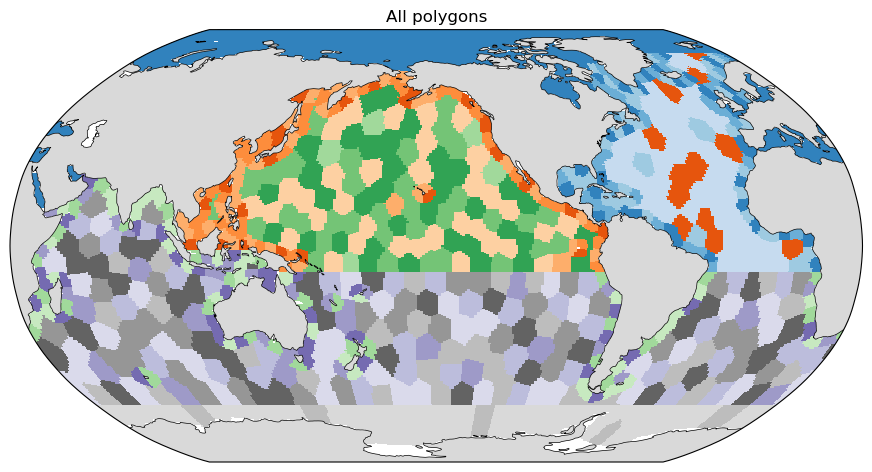

In [9]:
# Global view — all polygons colored by id, selected polygons highlighted in red.
fig, ax = plt.subplots(
    figsize=(11, 6),
    subplot_kw={"projection": ccrs.Robinson(central_longitude=-150)},
)

# All polygons, colored by id with a cyclic categorical cmap.
ax.pcolormesh(
    map_polygon_id.TLONG, map_polygon_id.TLAT, map_polygon_id,
    cmap="tab20c", shading="auto",
    transform=ccrs.PlateCarree(),
)

ax.add_feature(cfeature.LAND, facecolor="0.85", zorder=2)
ax.coastlines(linewidth=0.5, zorder=3)
ax.set_global()
ax.set_title(f"All polygons")
plt.show()

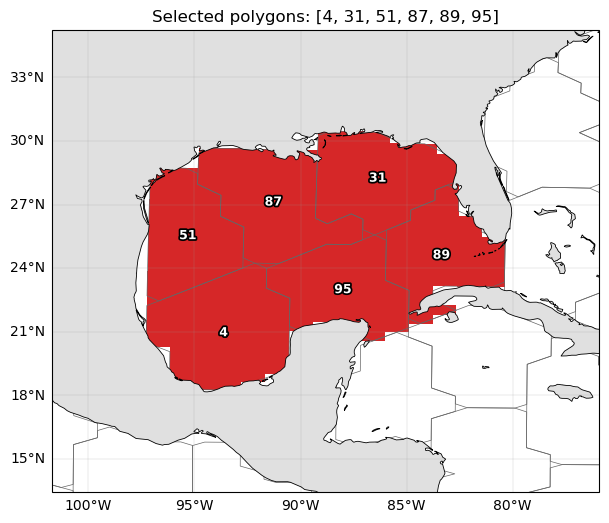

In [10]:
# Cells belonging to selected polygons (False on land and unselected ocean).
selected_cells = map_polygon_id.isin(polygon_id) & map_polygon_id.notnull()

# Zoom extent = min/max of selected polygons' lat/lon ± tolerance.
sel_lat = map_polygon_id.TLAT.where(selected_cells)
sel_lon = map_polygon_id.TLONG.where(selected_cells)
lat_min, lat_max = float(sel_lat.min()), float(sel_lat.max())
lon_min, lon_max = float(sel_lon.min()), float(sel_lon.max())

tolerance = 5.0  # degrees of padding around the selection
extent = [
    lon_min - tolerance, lon_max + tolerance,
    lat_min - tolerance, lat_max + tolerance,
]

# Center the projection on the selection so axis labels stay tidy and the
# dateline doesn't bisect the figure.  POP TLONG is in [0, 360);
# normalize the centre to (-180, 180].
central_lon = ((0.5 * (lon_min + lon_max) + 180) % 360) - 180

proj = ccrs.PlateCarree(central_longitude=central_lon)
fig, ax = plt.subplots(figsize=(9, 6), subplot_kw={"projection": proj})

# Outline every polygon that has any cells in the (padded) zoom window — we
# skip the rest for speed.
in_extent = (
    (map_polygon_id.TLAT >= extent[2])
    & (map_polygon_id.TLAT <= extent[3])
    & (map_polygon_id.TLONG >= extent[0])
    & (map_polygon_id.TLONG <= extent[1])
)
visible_ids = np.unique(map_polygon_id.where(in_extent).values)
visible_ids = visible_ids[~np.isnan(visible_ids)].astype(int)

TLONG = map_polygon_id.TLONG.values
TLAT = map_polygon_id.TLAT.values
poly_id_arr = map_polygon_id.values
for p in visible_ids:
    poly_mask = (poly_id_arr == p).astype(float)
    ax.contour(
        TLONG, TLAT, poly_mask, levels=[0.5],
        colors="0.4", linewidths=0.5,
        transform=ccrs.PlateCarree(),
    )

# Fill in the selected polygons.
fill = selected_cells.astype(float).where(map_polygon_id.notnull())
fill_cmap = ListedColormap([(0, 0, 0, 0), "tab:red"])
ax.pcolormesh(
    TLONG, TLAT, fill.values,
    cmap=fill_cmap, shading="auto", vmin=0, vmax=1,
    transform=ccrs.PlateCarree(),
)

# Label each selected polygon at its centroid.
for p in polygon_id:
    cells = (map_polygon_id == p)
    lat_c = float(map_polygon_id.TLAT.where(cells).mean())
    lon_c = float(map_polygon_id.TLONG.where(cells).mean())
    ax.text(
        lon_c, lat_c, str(p),
        transform=ccrs.PlateCarree(),
        ha="center", va="center", fontsize=9, fontweight="bold",
        color="white",
        path_effects=[mpe.withStroke(linewidth=2.5, foreground="black")],
    )

# Map decorations
ax.add_feature(cfeature.LAND, facecolor="0.88", zorder=2)
ax.coastlines(linewidth=0.6, zorder=3)
gl = ax.gridlines(draw_labels=True, linewidth=0.3, color="0.6", alpha=0.5)
gl.top_labels = False
gl.right_labels = False

ax.set_extent(extent, crs=ccrs.PlateCarree())
ax.set_title(f"Selected polygons: {polygon_id}")
plt.show()

## 4. $\gamma_\mathrm{OAE}$ and $\gamma_\mathrm{DOR}$ timeseries

One panel per injection season. Each polygon has a fixed color; OAE is solid, DOR is dashed. Across polygons and seasons, $\gamma_\mathrm{DOR}$ sits above $\gamma_\mathrm{OAE}$ because $\eta_\mathrm{max} < 1$ in the ocean (Zhou et al., Fig. 3).

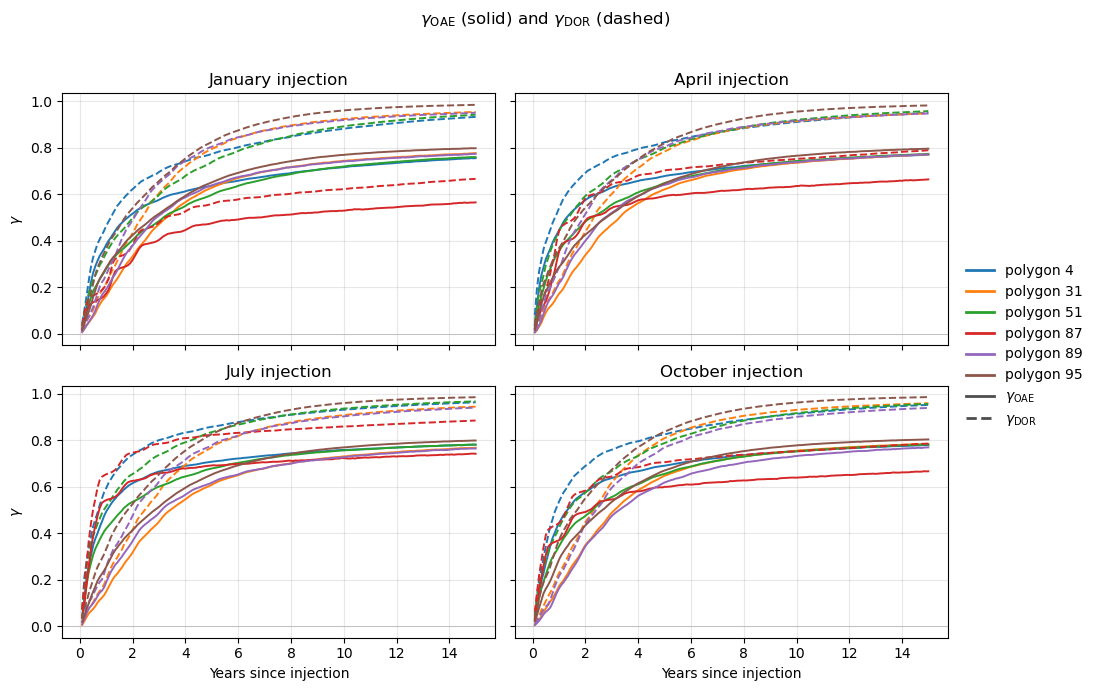

In [11]:
# Four-panel plot — one panel per injection season.
# Each polygon has a fixed color; γ_OAE is solid, γ_DOR is dashed.
colors = plt.cm.tab10(np.arange(len(polygon_id)))

fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True, sharey=True)

for ax, season in zip(axes.flat, ds.season.values):
    sub = ds.sel(season=season)
    for color, pid in zip(colors, polygon_id):
        dt = sub.time_delta.sel(polygon_id=pid)
        # time_delta is days per monthly timestep -> years since injection
        years = dt.cumsum(dim="time") / 365.25
        ax.plot(years, sub.gamma_oae.sel(polygon_id=pid),
                color=color, linestyle="-", linewidth=1.4)
        ax.plot(years, sub.gamma_dor.sel(polygon_id=pid),
                color=color, linestyle="--", linewidth=1.4)
    ax.axhline(0, color="0.7", linewidth=0.5)
    ax.set_title(f"{season} injection")
    ax.grid(alpha=0.3)

for ax in axes[-1, :]:
    ax.set_xlabel("Years since injection")
for ax in axes[:, 0]:
    ax.set_ylabel(r"$\gamma$")

# Combined legend: polygon color + line style
poly_handles = [plt.Line2D([0], [0], color=c, lw=2) for c in colors]
style_handles = [
    plt.Line2D([0], [0], color="0.3", lw=2, linestyle="-",
               label=r"$\gamma_\mathrm{OAE}$"),
    plt.Line2D([0], [0], color="0.3", lw=2, linestyle="--",
               label=r"$\gamma_\mathrm{DOR}$"),
]
fig.legend(
    poly_handles + style_handles,
    [f"polygon {pid}" for pid in polygon_id]
    + [r"$\gamma_\mathrm{OAE}$", r"$\gamma_\mathrm{DOR}$"],
    loc="center right",
    bbox_to_anchor=(1.0, 0.5),
    frameon=False,
)
fig.suptitle(r"$\gamma_\mathrm{OAE}$ (solid) and $\gamma_\mathrm{DOR}$ (dashed)")
fig.tight_layout(rect=[0, 0, 0.88, 0.96])
plt.show()

## 5. $\gamma_\mathrm{ACE}$ timeseries

For $R = 1$ (HCO₃⁻ input), $\gamma_\mathrm{ACE}$ is generally negative: the ocean outgasses some of the CO₂ initially captured upstream because the combined DIC + alkalinity addition drives the carbonate system away from equilibrium. The magnitude varies with location and season — the same circulation and gas-exchange timescales that set $\gamma_\mathrm{OAE}$ and $\gamma_\mathrm{DOR}$ control the offset.

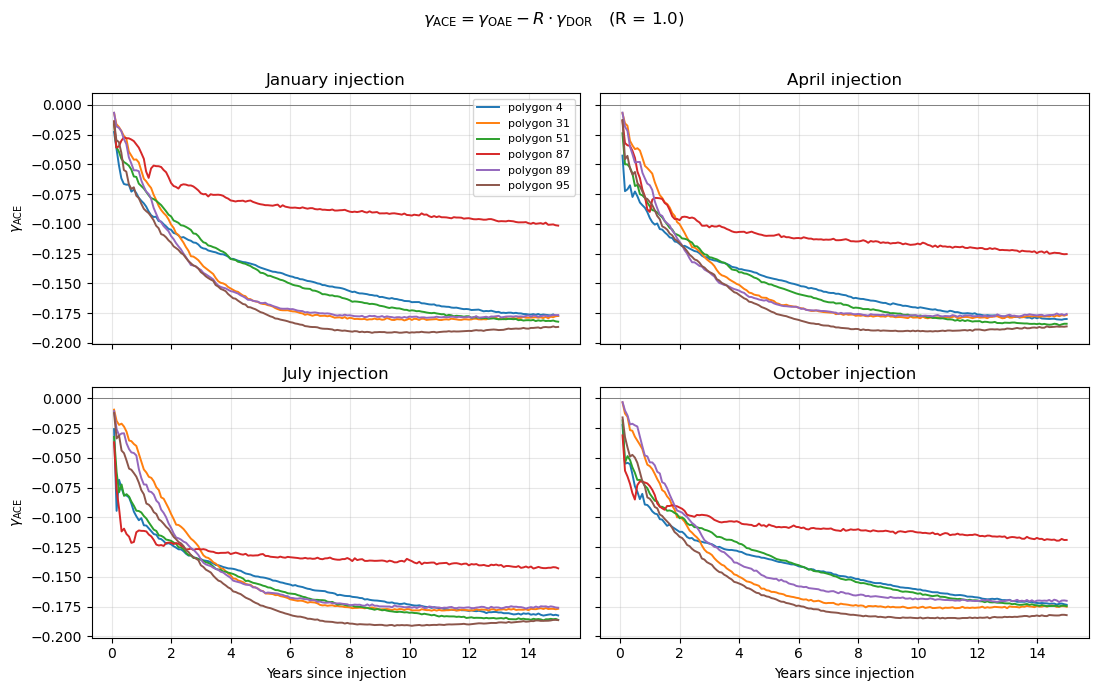

In [12]:
# Four-panel plot of γ_ACE — one panel per injection season.
# For R = 1 (HCO3- input), γ_ACE is generally negative: ocean outgassing
# partially offsets the CO2 initially captured upstream (Zhou et al.).
colors = plt.cm.tab10(np.arange(len(polygon_id)))

fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True, sharey=True)

for ax, season in zip(axes.flat, ds.season.values):
    sub = ds.sel(season=season)
    for color, pid in zip(colors, polygon_id):
        dt = sub.time_delta.sel(polygon_id=pid)
        years = dt.cumsum(dim="time") / 365.25
        ax.plot(years, sub.gamma_ace.sel(polygon_id=pid),
                color=color, linewidth=1.4, label=f"polygon {pid}")
    ax.axhline(0, color="0.5", linewidth=0.7)
    ax.set_title(f"{season} injection")
    ax.grid(alpha=0.3)

for ax in axes[-1, :]:
    ax.set_xlabel("Years since injection")
for ax in axes[:, 0]:
    ax.set_ylabel(r"$\gamma_\mathrm{ACE}$")

axes[0, 0].legend(loc="best", fontsize=8)
fig.suptitle(
    rf"$\gamma_\mathrm{{ACE}} = \gamma_\mathrm{{OAE}} - R\cdot\gamma_\mathrm{{DOR}}$"
    rf"   (R = {ds.attrs['R']})"
)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## 6. $\gamma_\mathrm{ACE}$ summary — mean across seasons and polygons

A single $\gamma_\mathrm{ACE}$ line obtained by averaging across all (season × polygon) combinations, with $\pm 1\sigma$ shading showing the spread.

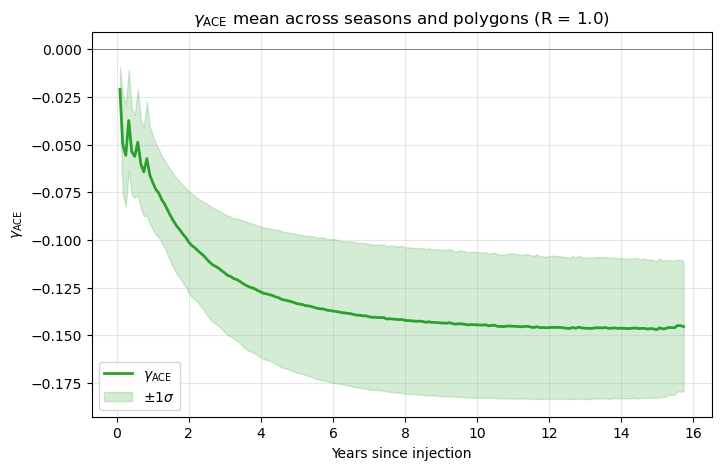

γ_ACE at 16 years since injection: -0.145 ± 0.034 (mean ± 1σ across 4 seasons × 6 polygons)


In [13]:
# Mean and 1-σ spread across (season, polygon_id) for γ_ACE.
mean_dims = ("season", "polygon_id")

# time_delta varies slightly across (season, polygon_id) because of injection
# month and per-region time grids; take its mean so we have a single
# "years since injection" axis.
years = ds.time_delta.mean(dim=mean_dims).cumsum(dim="time") / 365.25

m = ds.gamma_ace.mean(dim=mean_dims)
s = ds.gamma_ace.std(dim=mean_dims)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(years, m, color="C2", lw=2, label=ds.gamma_ace.attrs.get("long_name", "gamma_ace"))
ax.fill_between(years, m - s, m + s, color="C2", alpha=0.2, label=r"$\pm 1\sigma$")

ax.axhline(0, color="0.5", linewidth=0.7)
ax.set_xlabel("Years since injection")
ax.set_ylabel(r"$\gamma_\mathrm{ACE}$")
ax.set_title(
    f"$\\gamma_\\mathrm{{ACE}}$ mean across seasons and polygons (R = {ds.attrs['R']})"
)
ax.legend(loc="best")
ax.grid(alpha=0.3)
plt.show()

# Report the final γ_ACE value at the end of the simulation.
final_years = float(years.isel(time=-1))
final_mean = float(m.isel(time=-1))
final_std = float(s.isel(time=-1))
print(
    f"γ_ACE at {final_years:.0f} years since injection: "
    f"{final_mean:.3f} ± {final_std:.3f} "
    f"(mean ± 1σ across {ds.sizes['season']} seasons × {len(polygon_id)} polygons)"
)